In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
# Machine Learning
from sklearn.model_selection import train_test_split # splits dataset for traing and testing purpose.
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [ ]:
df = pd.read_csv('/content/new_york_listings_2024.csv')
df

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,1312228,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.683710,-73.964610,Private room,55.0,...,2015-12-20,0.03,1,0,0,No License,5.0,1,1,Not specified
1,45277537,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,2023-05-01,0.24,139,364,2,No License,4.67,2,1,1
2,971353993633883038,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,2023-12-18,1.67,1,343,6,Exempt,4.17,1,2,1
3,3857863,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,2023-09-17,1.38,2,363,12,No License,4.64,1,1,1
4,40896611,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,...,2023-12-03,0.24,133,335,3,No License,4.91,Studio,1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20753,24736896,Rental unit in New York · ★4.75 · 1 bedroom · ...,186680487,Henry D,Manhattan,Lower East Side,40.711380,-73.991560,Private room,45.0,...,2023-09-29,1.81,1,157,12,No License,4.75,1,1,1
20754,2835711,Rental unit in New York · ★4.46 · 1 bedroom · ...,3237504,Aspen,Manhattan,Greenwich Village,40.730580,-74.000700,Entire home/apt,105.0,...,2023-07-01,0.48,1,0,1,No License,4.46,1,2,1
20755,51825274,Rental unit in New York · ★4.93 · 1 bedroom · ...,304317395,Jeff,Manhattan,Hell's Kitchen,40.757350,-73.993430,Entire home/apt,299.0,...,2023-12-08,2.09,1,0,27,No License,4.93,1,1,1
20756,782661008019550832,Rental unit in New York · ★5.0 · 1 bedroom · 1...,163083101,Marissa,Manhattan,Chinatown,40.713750,-73.991470,Entire home/apt,115.0,...,2023-09-17,0.91,1,363,7,No License,5.0,1,1,1


In [ ]:
print(df.shape)
print(df.head())

(20758, 22)
                   id                                               name  \
0             1312228         Rental unit in Brooklyn · ★5.0 · 1 bedroom   
1            45277537  Rental unit in New York · ★4.67 · 2 bedrooms ·...   
2  971353993633883038  Rental unit in New York · ★4.17 · 1 bedroom · ...   
3             3857863  Rental unit in New York · ★4.64 · 1 bedroom · ...   
4            40896611  Condo in New York · ★4.91 · Studio · 1 bed · 1...   

     host_id           host_name neighbourhood_group       neighbourhood  \
0    7130382              Walter            Brooklyn        Clinton Hill   
1   51501835            Jeniffer           Manhattan      Hell's Kitchen   
2  528871354              Joshua           Manhattan             Chelsea   
3   19902271  John And Catherine           Manhattan  Washington Heights   
4   61391963      Stay With Vibe           Manhattan         Murray Hill   

    latitude  longitude        room_type  price  ...  last_review  \
0  40

In [ ]:
df.columns

Index(['id', 'name', 'host_id', 'host_name', 'neighbourhood_group',
       'neighbourhood', 'latitude', 'longitude', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'last_review',
       'reviews_per_month', 'calculated_host_listings_count',
       'availability_365', 'number_of_reviews_ltm', 'license', 'rating',
       'bedrooms', 'beds', 'baths'],
      dtype='object')

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20758 entries, 0 to 20757
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20758 non-null  int64  
 1   name                            20758 non-null  object 
 2   host_id                         20758 non-null  int64  
 3   host_name                       20758 non-null  object 
 4   neighbourhood_group             20758 non-null  object 
 5   neighbourhood                   20758 non-null  object 
 6   latitude                        20758 non-null  float64
 7   longitude                       20758 non-null  float64
 8   room_type                       20758 non-null  object 
 9   price                           20758 non-null  float64
 10  minimum_nights                  20758 non-null  int64  
 11  number_of_reviews               20758 non-null  int64  
 12  last_review                     

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,20758.0,3.034044e+17,3.901216e+17,2595.000000,2.708808e+07,4.993003e+07,7.216019e+17,1.054376e+18
host_id,20758.0,1.749316e+08,1.725541e+08,1678.000000,2.041738e+07,1.087271e+08,3.144102e+08,5.504035e+08
latitude,20758.0,4.072680e+01,6.029351e-02,40.500314,4.068415e+01,4.072282e+01,4.076310e+01,4.091115e+01
longitude,20758.0,-7.393916e+01,6.140306e-02,-74.249840,-7.398071e+01,-7.394959e+01,-7.391746e+01,-7.371365e+01
price,20758.0,1.877766e+02,1.022797e+03,10.000000,8.000000e+01,1.250000e+02,1.990000e+02,1.000000e+05
minimum_nights,20758.0,2.855844e+01,3.353652e+01,1.000000,3.000000e+01,3.000000e+01,3.000000e+01,1.250000e+03
number_of_reviews,20758.0,4.264260e+01,7.356165e+01,1.000000,4.000000e+00,1.400000e+01,4.900000e+01,1.865000e+03
reviews_per_month,20758.0,1.257910e+00,1.904661e+00,0.010000,2.100000e-01,6.500000e-01,1.800000e+00,7.549000e+01
calculated_host_listings_count,20758.0,1.884411e+01,7.091083e+01,1.000000,1.000000e+00,2.000000e+00,5.000000e+00,7.130000e+02
availability_365,20758.0,2.059903e+02,1.350878e+02,0.000000,8.700000e+01,2.150000e+02,3.530000e+02,3.650000e+02


In [ ]:
# Missing Values
print(df.isnull().sum())

id                                0
name                              0
host_id                           0
host_name                         0
neighbourhood_group               0
neighbourhood                     0
latitude                          0
longitude                         0
room_type                         0
price                             0
minimum_nights                    0
number_of_reviews                 0
last_review                       0
reviews_per_month                 0
calculated_host_listings_count    0
availability_365                  0
number_of_reviews_ltm             0
license                           0
rating                            0
bedrooms                          0
beds                              0
baths                             0
dtype: int64


In [ ]:
#To check duplicate values.
df.duplicated().sum()

np.int64(0)

In [ ]:
num_cols = df.select_dtypes(include = ['int64','float64']).columns
num_cols

Index(['id', 'host_id', 'latitude', 'longitude', 'price', 'minimum_nights',
       'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365',
       'number_of_reviews_ltm', 'beds'],
      dtype='object')

In [ ]:
cat_cols = df.select_dtypes(include = ['object','category']).columns
cat_cols

Index(['name', 'host_name', 'neighbourhood_group', 'neighbourhood',
       'room_type', 'last_review', 'license', 'rating', 'bedrooms', 'baths'],
      dtype='object')

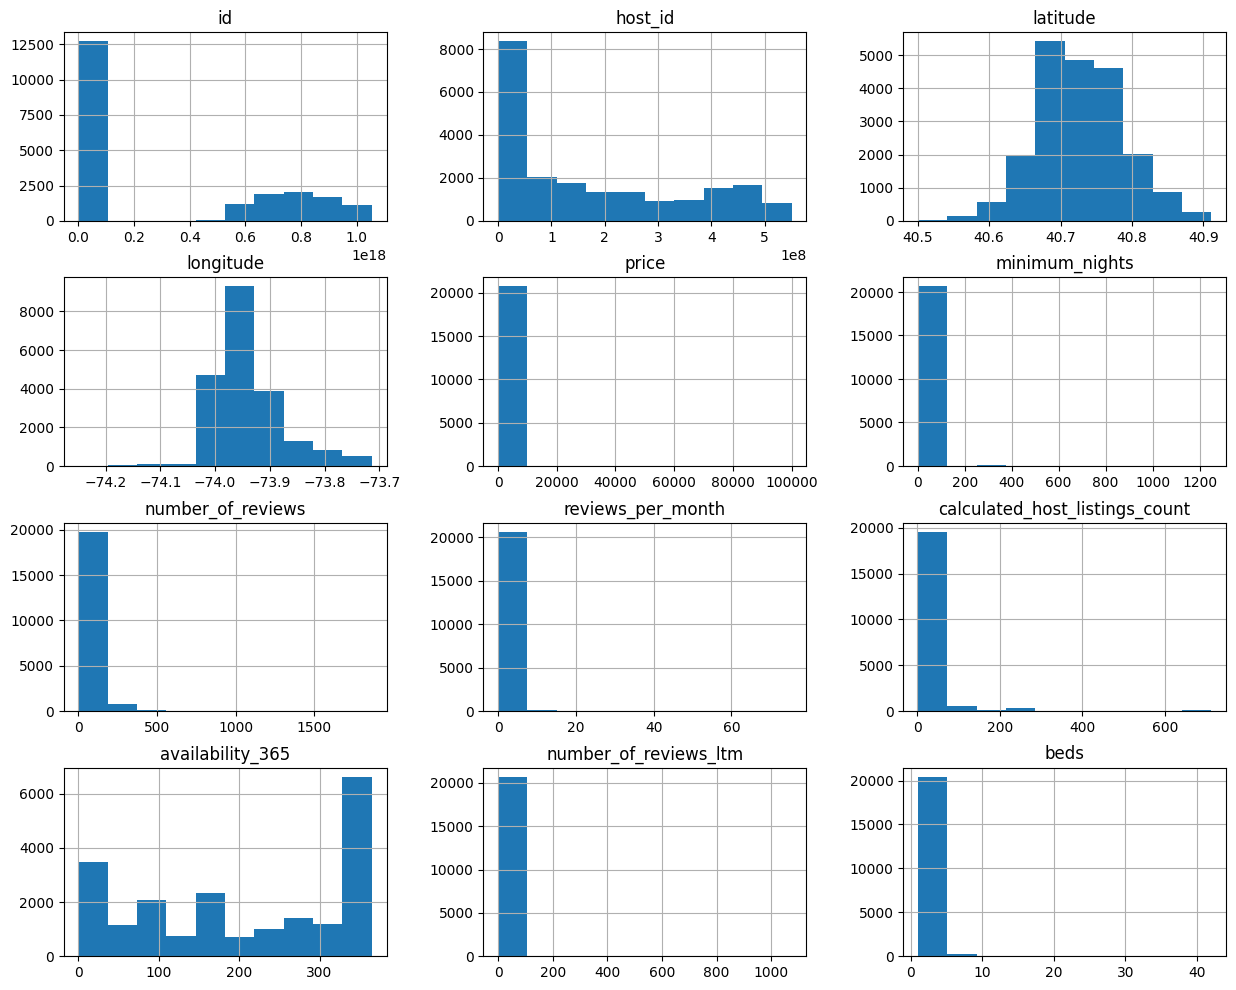

In [ ]:
df.hist(figsize = (15,12))
plt.show()

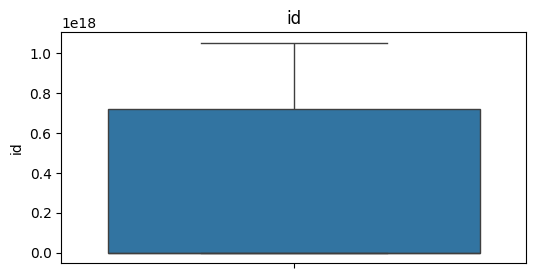

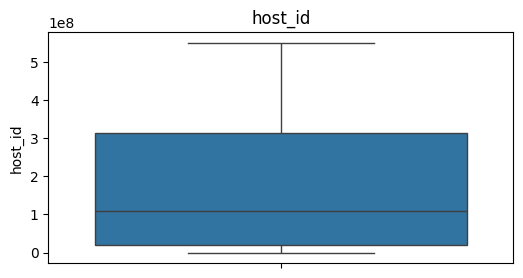

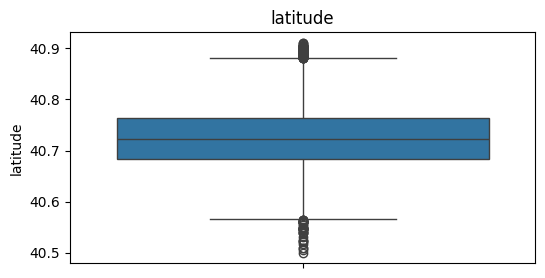

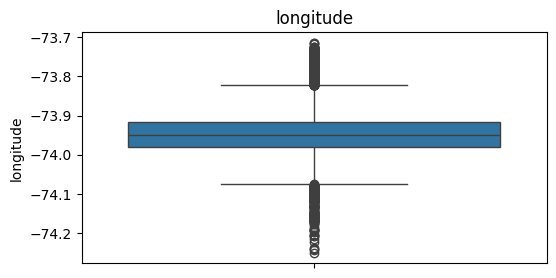

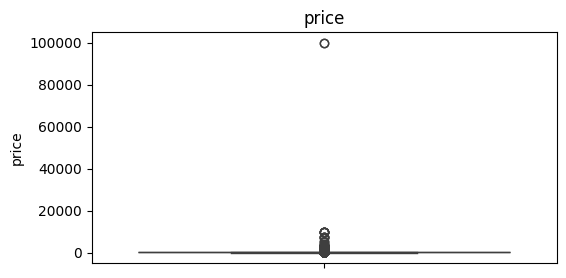

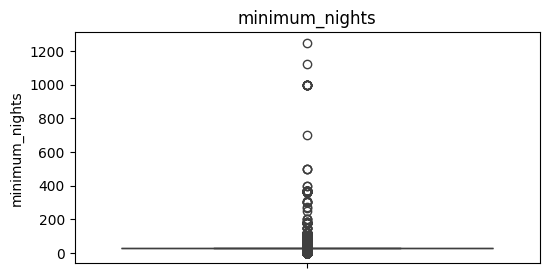

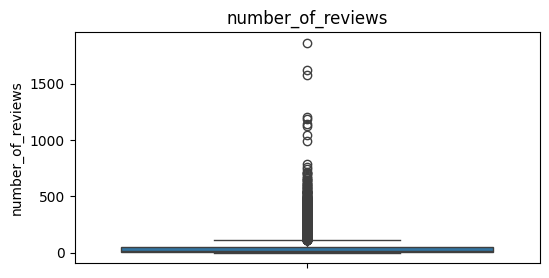

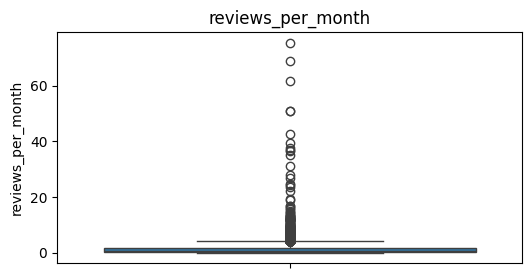

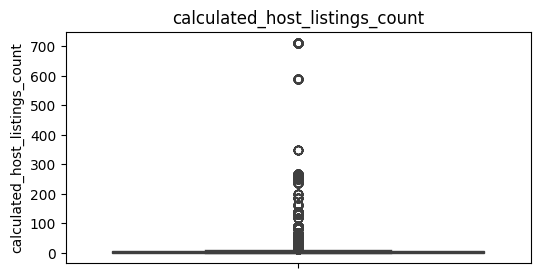

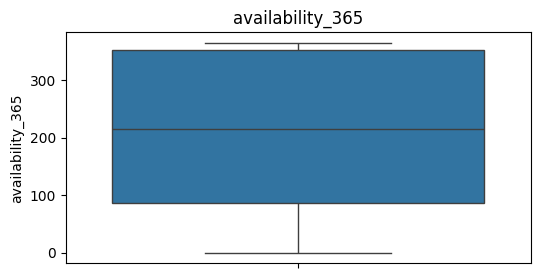

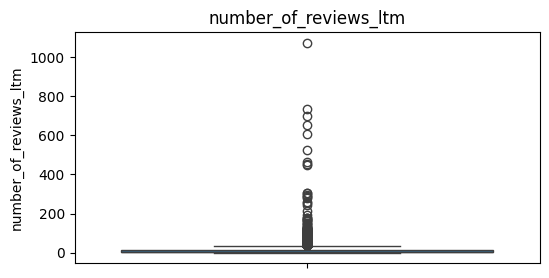

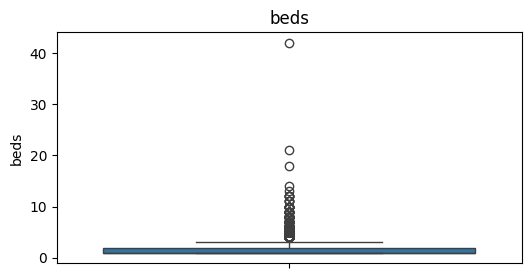

In [ ]:
# Outlier
for col in num_cols:
  plt.figure(figsize = (6,3))
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

In [ ]:
exclude_cols = ['id', 'host_id','availability_365']
num_cols = [col for col in num_cols if col not in exclude_cols]
print(num_cols)

['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'number_of_reviews_ltm', 'beds']


In [ ]:
# Outlier Treatment
for col in num_cols:
  Q1 = df[col].quantile(0.25)
  Q3 = df[col].quantile(0.75)

  IQR = Q3-Q1

  lower_range = Q1 - 1.5*IQR
  upper_range = Q3 + 1.5*IQR

  df[col] = np.where(df[col] > upper_range, upper_range, df[col])
  df[col] = np.where(df[col]< lower_range, lower_range, df[col])

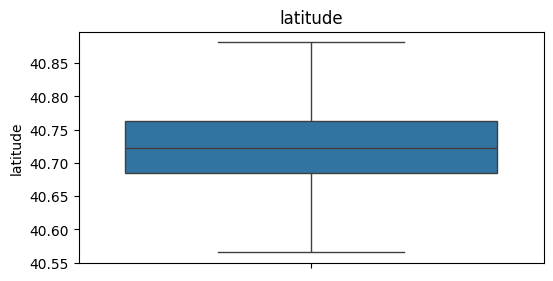

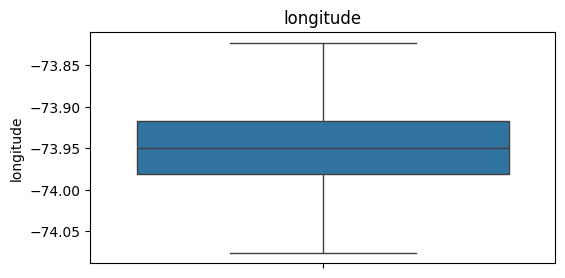

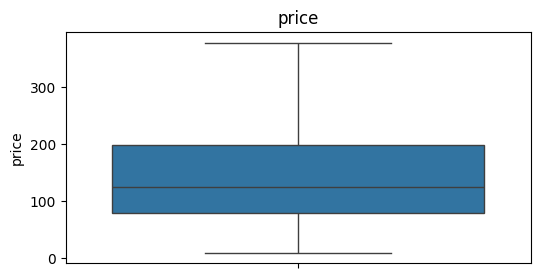

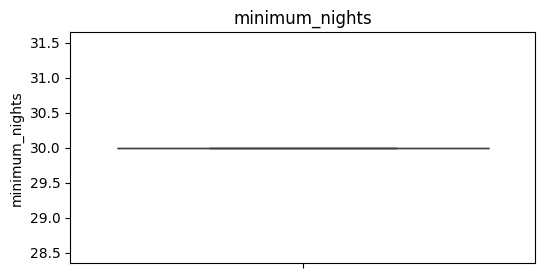

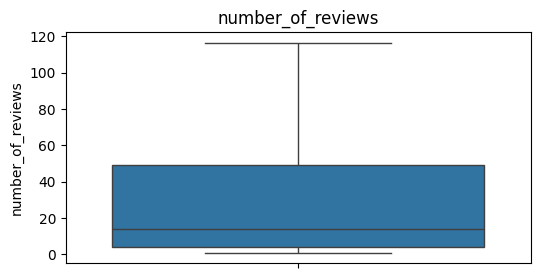

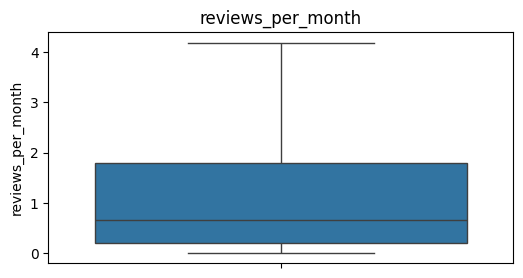

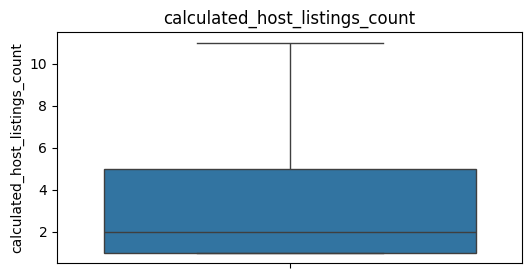

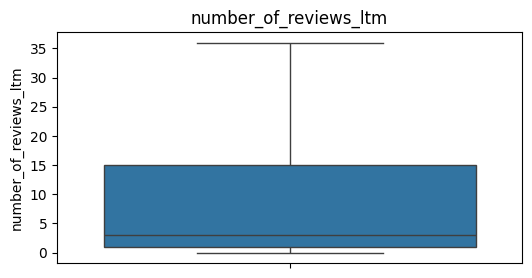

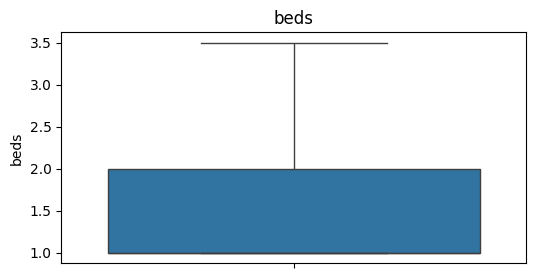

In [ ]:
for col in num_cols:
  plt.figure(figsize =(6,3))
  sns.boxplot(df[col])
  plt.title(col)
  plt.show()

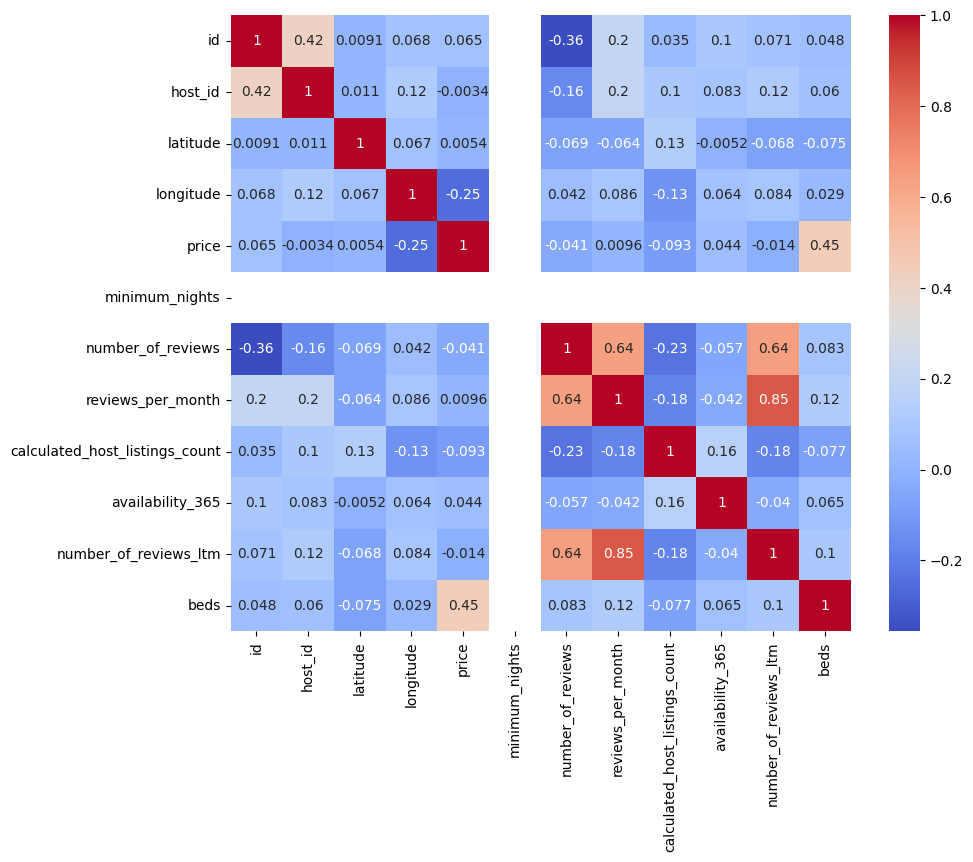

In [ ]:
# Correlation Analysis
corr = df.corr(numeric_only=True)
plt.figure(figsize =(10,8))
sns.heatmap(corr, annot = True, cmap = 'coolwarm')
plt.show()

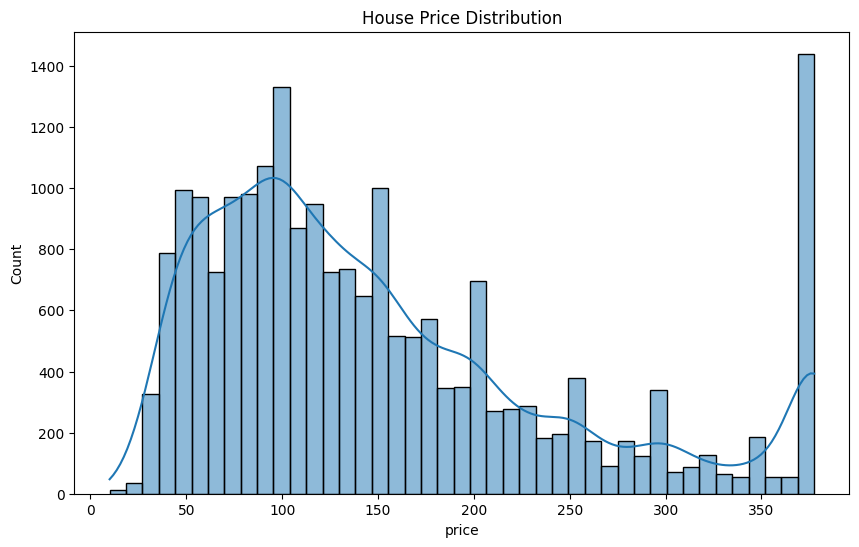

In [ ]:
# House Price Distrubtion
plt.figure(figsize = (10, 6))
sns.histplot(df['price'],kde = True)
plt.title('House Price Distribution')
plt.show()

In [ ]:
df = df.drop(columns=['id', 'name', 'host_id', 'host_name', 'last_review', 'latitude', 'longitude', 'license', 'rating', 'bedrooms', 'baths'])

print(df.columns)

Index(['neighbourhood_group', 'neighbourhood', 'room_type', 'price',
       'minimum_nights', 'number_of_reviews', 'reviews_per_month',
       'calculated_host_listings_count', 'availability_365',
       'number_of_reviews_ltm', 'beds'],
      dtype='object')


In [ ]:
# 0ne_hot Encoding
df = pd.get_dummies(df, columns=['room_type', 'neighbourhood_group', 'neighbourhood'])

In [ ]:
df.head()

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,beds,room_type_Entire home/apt,room_type_Hotel room,...,neighbourhood_Westerleigh,neighbourhood_Whitestone,neighbourhood_Williamsbridge,neighbourhood_Williamsburg,neighbourhood_Willowbrook,neighbourhood_Windsor Terrace,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodrow,neighbourhood_Woodside
0,55.0,30.0,3.0,0.03,1.0,0,0.0,1.0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,144.0,30.0,9.0,0.24,11.0,364,2.0,1.0,True,False,...,False,False,False,False,False,False,False,False,False,False
2,187.0,30.0,6.0,1.67,1.0,343,6.0,2.0,True,False,...,False,False,False,False,False,False,False,False,False,False
3,120.0,30.0,116.5,1.38,2.0,363,12.0,1.0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,85.0,30.0,11.0,0.24,11.0,335,3.0,1.0,True,False,...,False,False,False,False,False,False,False,False,False,False


In [ ]:
df = df.astype(float).astype(int)
df

,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,beds,room_type_Entire home/apt,room_type_Hotel room,...,neighbourhood_Westerleigh,neighbourhood_Whitestone,neighbourhood_Williamsbridge,neighbourhood_Williamsburg,neighbourhood_Willowbrook,neighbourhood_Windsor Terrace,neighbourhood_Woodhaven,neighbourhood_Woodlawn,neighbourhood_Woodrow,neighbourhood_Woodside
0,55,30,3,0,1,0,0,1,0,0,...,0,0,0,0,0,0,0,0,0,0
1,144,30,9,0,11,364,2,1,1,0,...,0,0,0,0,0,0,0,0,0,0
2,187,30,6,1,1,343,6,2,1,0,...,0,0,0,0,0,0,0,0,0,0
3,120,30,116,1,2,363,12,1,0,0,...,0,0,0,0,0,0,0,0,0,0
4,85,30,11,0,11,335,3,1,1,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
20753,45,30,116,1,1,157,12,1,0,0,...,0,0,0,0,0,0,0,0,0,0
20754,105,30,56,0,1,0,1,2,1,0,...,0,0,0,0,0,0,0,0,0,0
20755,299,30,60,2,1,0,27,1,1,0,...,0,0,0,0,0,0,0,0,0,0
20756,115,30,7,0,1,363,7,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
X = df.drop('price', axis=1)
y = df['price']

print(X.head())
print(y.head())

   minimum_nights  number_of_reviews  reviews_per_month  \
0              30                  3                  0   
1              30                  9                  0   
2              30                  6                  1   
3              30                116                  1   
4              30                 11                  0   

   calculated_host_listings_count  availability_365  number_of_reviews_ltm  \
0                               1                 0                      0   
1                              11               364                      2   
2                               1               343                      6   
3                               2               363                     12   
4                              11               335                      3   

   beds  room_type_Entire home/apt  room_type_Hotel room  \
0     1                          0                     0   
1     1                          1                     0

In [ ]:
# Train_Test_Split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()

In [ ]:
# Train the Model
model.fit(X_train, y_train)

LinearRegression()

In [ ]:
print(model.coef_)

[ 1.54895456e-14 -2.29411943e-01  3.12540309e+00 -4.45982474e+00
  4.54267775e-02  3.01386525e-02  4.38528249e+01  1.28541171e+01
  6.22505181e+01 -2.73585387e+01 -4.77460965e+01 -2.10321568e+01
  8.90974436e+00  5.10187400e+01 -1.10916661e+01 -2.78046615e+01
 -1.45491797e+01 -6.15369375e+01  2.53353615e+01  6.11237147e-01
 -1.14899172e+00 -1.93904991e+01  1.98162220e+01 -2.59246687e+01
  1.20380307e+01  8.91451032e+00 -1.61750500e+01 -2.40262416e+00
 -1.51640163e+01 -5.85860287e+00  1.63153245e+01 -2.09765553e+01
 -1.48757574e+01 -5.07904945e+01  5.65060929e+01  4.84084540e+01
 -4.34768484e+01  7.31075035e+01 -3.10599208e+00 -2.15216350e+01
 -2.77029592e+01  5.99471402e+01 -9.50771519e+00 -3.62388182e+01
 -1.45387025e+01 -9.11533674e+00 -2.00935586e+01  4.71994810e+01
  1.25934406e+01  9.91818700e-01  3.01772635e+01 -9.56919368e+01
 -9.60183758e+00  9.86215527e+00  4.31741248e+01  9.24345052e+00
 -1.19792651e+00  2.73120995e+01  3.06727016e+01 -1.57199956e+01
  4.02368628e+01 -2.01013

In [ ]:
print(model.intercept_)

81.4087085023256


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
comparison = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred})
comparison

,Actual,Predicted
10317,64,108.578299
4074,200,55.758676
9060,84,118.913689
11286,30,51.237367
8254,124,110.655492
...,...,...
20286,117,199.174644
8233,49,35.417413
11518,124,167.507678
7947,125,243.175346


In [ ]:
from sklearn.metrics import mean_squared_error,mean_absolute_error,root_mean_squared_error

In [ ]:
# Calculate MAE
mae = mean_absolute_error(y_test, y_pred)
print('Mean Absolute Error:', mae)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
print('Root Mean Squared Error:', rmse)

Mean Absolute Error: 54.58658644155509
Root Mean Squared Error: 71.87481747991893


R-squared Score: 0.4017055989817847


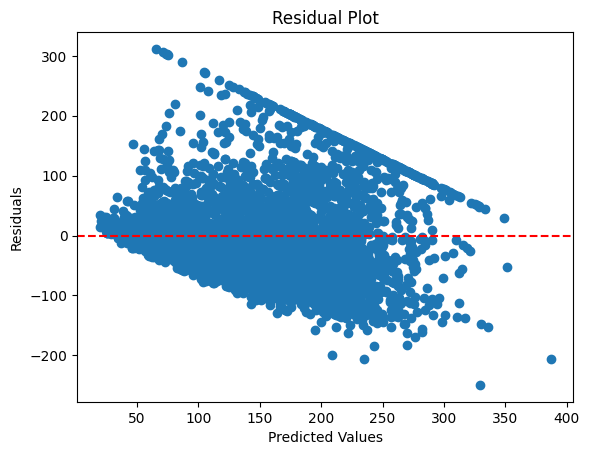

In [ ]:
from sklearn.metrics import r2_score

# Calculate R square score
r2 = r2_score(y_test, y_pred)
print('R-squared Score:', r2)

# plot residuals
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

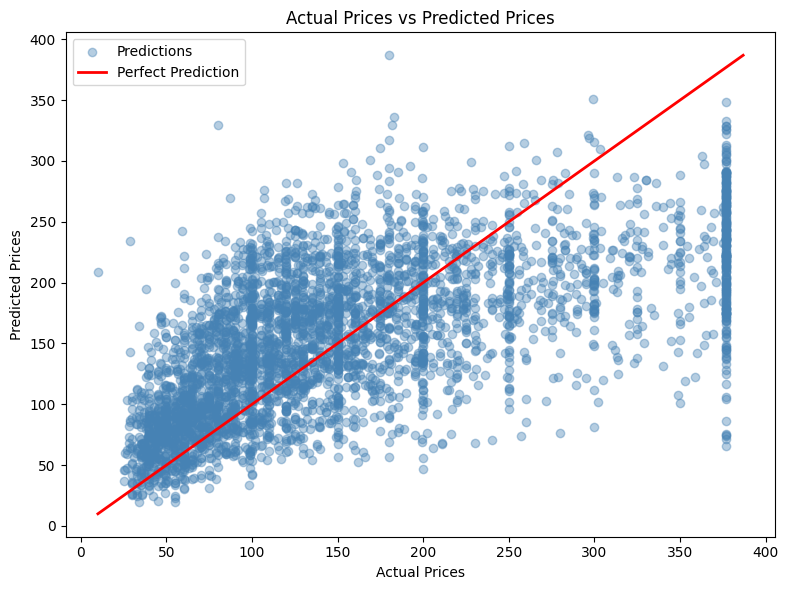

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='steelblue', alpha=0.4, label='Predictions')

min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linewidth=2, label='Perfect Prediction')

plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual Prices vs Predicted Prices')
plt.legend()
plt.tight_layout()
plt.show()

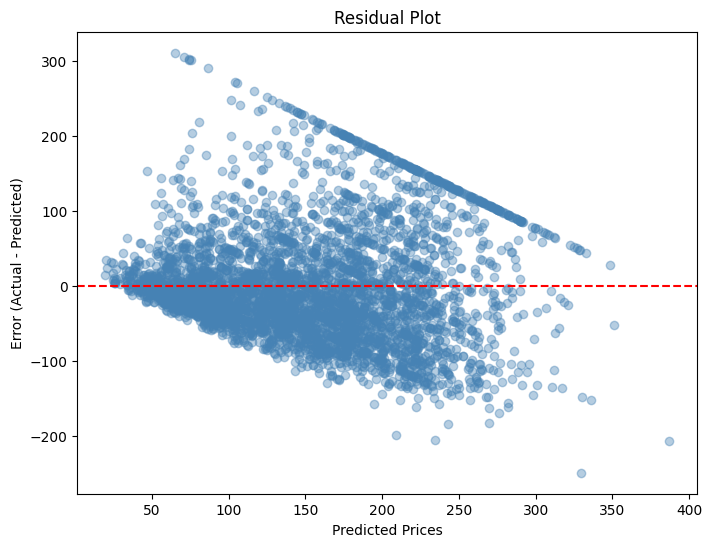

In [ ]:
residuals = y_test - y_pred

# Residual Plot
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, color='steelblue', alpha=0.4)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel('Predicted Prices')
plt.ylabel('Error (Actual - Predicted)')
plt.title('Residual Plot')
plt.show()

The model performs better on cheap listings. This is because most listings in the dataset are low-priced, giving the model more data to learn from. Expensive listings are rare and unpredictable, leading to higher errors.